In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = './data/'
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

# get the metadata tables
units_table = cache.get_unit_table()
channels_table = cache.get_channel_table()
probes_table = cache.get_probe_table()
behavior_sessions_table = cache.get_behavior_session_table()
ecephys_sessions_table = cache.get_ecephys_session_table()

In [3]:
session_id = 1065437523 #1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Load Relevant Data

In [4]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()
unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))
good_units = unit_channels.loc[good_unit_filter]


# Unit info
unit_indices = np.array(good_units.index)
spike_times = dict([(i,session.spike_times[i]) for i in unit_indices])
structures = dict(good_units.structure_acronym)

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
# Active stimulus
active_stimulus_presentations = stimulus_presentations[stimulus_presentations["active"]]
# Active Stimulus: Time, Name, Is Change
onset_times = active_stimulus_presentations['start_time'].values
image_names = active_stimulus_presentations['image_name'].values
image_is_changes = active_stimulus_presentations['is_change'].values


# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

Pre Compute Bins

In [21]:
# Set bin size (~10 ms)
bin_size = 0.01
# Set # of bins (~10=100ms=0.1 sec)
num_bins = 60

# Create bin times relative to image onset (0ms, 10ms, 20ms, ..., 90ms)
bins_times_per_onset = np.linspace(0, (num_bins-1)*bin_size, num_bins)

# Create bin start and end times for entire active session
bin_start_times = []
bin_end_times = []

# For each image onset
for onset_time in onset_times:
    # Add bin start and end times
    bin_start_times += list(onset_time + bins_times_per_onset)
    bin_end_times += list(onset_time + bins_times_per_onset + bin_size)

# Convert them to numpy arrays (for efficiency)
bin_start_times = np.array(bin_start_times)
bin_end_times = np.array(bin_end_times)

Get Binned Spike Counts

In [22]:
# Get the # of image flashes and # of units
num_image_flashes = len(onset_times)
num_units = len(spike_times)

# Create data structure for binned spike counts
hist = np.zeros((num_image_flashes, num_bins, num_units))

# For each unit
for k, unit_idx in enumerate(unit_indices):
    # Select corresponding unit's spike times
    unit_spike_times = spike_times[unit_idx]

    # Find the correct indices of the unit spike times for each bin
    start_indices = np.searchsorted(unit_spike_times, bin_start_times)
    stop_indices = np.searchsorted(unit_spike_times, bin_end_times)

    # Get the counts for each bin
    counts = stop_indices - start_indices

    # Store them in our handy-dandy "histogram"
    hist[:,:,k] = counts.reshape(num_image_flashes, num_bins)

What Brain Region Each Acronym is Part Of

In [7]:
# Map Structure Acronym to Brain Region
acronym2region = {
    "APN": "Midbrain",
    "CA1": "Hippo",
    "CA3": "Hippo",
    "DG": "Hippo",
    "Eth": "Thalamus",
    "HPF": "Hippo",
    "LP": "Thalamus",
    "MB": "Midbrain",
    "MGd": "Midbrain",
    "MGm": "Midbrain",
    "MGv": "Midbrain",
    "MRN": "Midbrain",
    "NB": "UNKNOWN", # idk
    "NOT": "Midbrain",
    "PIL": "Thalamus",
    "POL": "Thalamus",
    "POST": "Hippo",
    "ProS": "Hippo",
    "SUB": "Hippo",
    "TH": "Thalamus",
    "VISal": "VIS",
    "VISam": "VIS",
    "VISl": "VIS",
    "VISp": "VIS",
    "VISpm": "VIS",
    "VISpm": "VIS",
    "VISrl": "VIS",
    "root": "UNKNOWN", # idk

    "SGN": "Thalamus",
    "PoT": "Thalamus",
    "PP": "Thalamus",
    "RN": "Midbrain", # i think
    "LT": "Midbrain",
}

#### Using Kernel Method and SVC to find the plots for bottom

In [8]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

##### Specifically finding the plot for the change decoding

In [10]:
y = image_is_changes.astype(int)

relative_time_axis = np.linspace(10, 100, 10) #used this to try and match the plot from above
num_time_bins = len(relative_time_axis)

region_groupings = { "VIS":["VISal", "VISam", "VISl", "VISp", "VISpm", "VISrl"],
    "LP": ["LP"],
    "LGd": ["LGd"],
    "SCm/MRN": ["SCm", "MRN"]}

colors = {"VIS": "green", "LP": "orange", "LGd": "blue", "SCm/MRN": "pink"}

svm = LinearSVC(C=1.0, dual=False)
cv = StratifiedKFold(n_splits=5, shuffle=False)
n_bootstraps = 2

mean_accuracies = {}
lower_bounds = {}
upper_bounds = {}

for group_name, acronyms in region_groupings.items():
    mask = np.zeros(num_units, dtype=bool)
    for i, unit_idx in enumerate(unit_indices):
        if structures.get(unit_idx) in acronyms:
            mask[i] = True

    if not np.any(mask):
        print(f"No units found for group {group_name}. Skipping.")
        continue
    group_hist = hist[:,:,mask]
    cumulative_spikes = np.cumsum(group_hist, axis=1)

    num_trials, num_time_bins, _ = cumulative_spikes.shape
    boot_scores = np.zeros((n_bootstraps, num_time_bins))

    for boot in range(n_bootstraps):
        change_indices = np.where(y == 1)[0]
        no_change_indices = np.where(y == 0)[0]
        num_majority = len(no_change_indices)
        oversampled_change = np.random.choice(change_indices, size=num_majority, replace=True)
        balanced_indices = np.concatenate([oversampled_change, no_change_indices])

        X_balanced = cumulative_spikes[balanced_indices, :, :]
        y_balanced = y[balanced_indices]
        
        for t in range(num_time_bins):
            X_t = X_balanced[:, t, :]
            fold_scores = []

            for train_idx, test_idx in cv.split(X_t, y_balanced):
                X_train = X_t[train_idx]
                y_train = y_balanced[train_idx]
                X_test = X_t[test_idx]
                y_test = y_balanced[test_idx]

                svm.fit(X_train, y_train)

                score = svm.score(X_test, y_test)
                fold_scores.append(score)
        boot_scores[boot, t] = np.mean(fold_scores)
        
    mean_accuracies[group_name] = np.mean(boot_scores, axis=0)
    lower_bounds[group_name] = np.percentile(boot_scores, 2.5, axis=0)
    upper_bounds[group_name] = np.percentile(boot_scores, 97.5, axis=0)

c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

No units found for group LGd. Skipping.


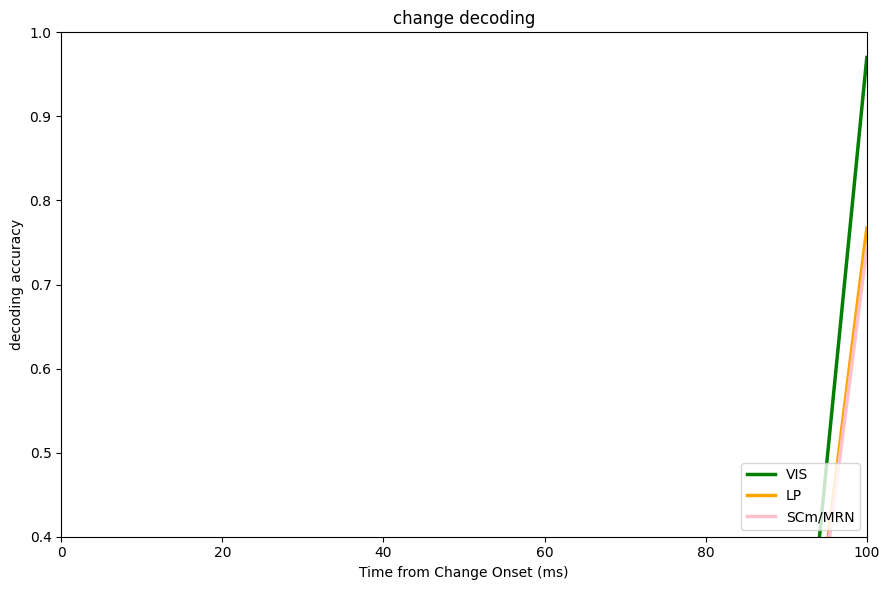

In [11]:
plt.figure(figsize=(9,6))

for group_name in mean_accuracies.keys():
    color = colors.get(group_name, "black")

    plt.plot(relative_time_axis, mean_accuracies[group_name], label=group_name, color=color, linewidth=2.5)
    plt.fill_between(relative_time_axis, lower_bounds[group_name], upper_bounds[group_name], color=color, alpha=0.2)


plt.xlabel('Time from Change Onset (ms)')
plt.ylabel('decoding accuracy')
plt.title('change decoding')

plt.xlim([0, 100])
plt.ylim([0.4, 1.0])

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Now we will do this for lick decoding plot 

In [23]:
if 'timestamps' in licks.columns:
    lick_times = licks['timestamps'].values
else:
    lick_times = licks.index.values

y_licks = np.zeros(len(onset_times), dtype=int)
response_window = 0.75
for i, start_time in enumerate(onset_times):
    valid_licks = lick_times[(lick_times >= start_time) & (lick_times <= start_time + response_window)]

    if len(valid_licks)>0:
        y_licks[i] = 1

y = y_licks

In [ ]:
y = y_licks
relative_time_axis = np.linspace(10, 600, 60) #used this to try and match the plot directly
num_time_bins = len(relative_time_axis)
region_groupings = {
    "VIS":["VISal", "VISam", "VISl", "VISp", "VISpm", "VISrl"],
    "SCm/MRN": ["SCm", "MRN"]
}
colors = {"VIS": "green", "SCm/MRN": "pink"}

svm = LinearSVC(C=1.0, dual=False)
cv = StratifiedKFold(n_splits=5, shuffle=False)
n_bootstraps = 2

mean_accuracies = {}
lower_bounds = {}
upper_bounds = {}

for group_name, acronyms in region_groupings.items():
    mask = np.zeros(num_units, dtype=bool)
    for i, unit_idx in enumerate(unit_indices):
        if structures.get(unit_idx) in acronyms:
            mask[i] = True

    if not np.any(mask):
        print(f"No units found for group {group_name}. Skipping.")
        continue
    group_hist = hist[:,:,mask]
    cumulative_spikes = np.cumsum(group_hist, axis=1)

    num_trials, num_time_bins, _ = cumulative_spikes.shape
    boot_scores = np.zeros((n_bootstraps, num_time_bins))

    for boot in range(n_bootstraps):
        change_indices = np.where(y == 1)[0]
        no_change_indices = np.where(y == 0)[0]
        num_majority = len(no_change_indices)
        oversampled_change = np.random.choice(change_indices, size=num_majority, replace=True)
        balanced_indices = np.concatenate([oversampled_change, no_change_indices])

        X_balanced = cumulative_spikes[balanced_indices, :, :]
        y_balanced = y[balanced_indices]
        
        for t in range(num_time_bins):
            X_t = X_balanced[:, t, :]
            fold_scores = []

            for train_idx, test_idx in cv.split(X_t, y_balanced):
                X_train = X_t[train_idx]
                y_train = y_balanced[train_idx]
                X_test = X_t[test_idx]
                y_test = y_balanced[test_idx]

                svm.fit(X_train, y_train)

                score = svm.score(X_test, y_test)
                fold_scores.append(score)
        boot_scores[boot, t] = np.mean(fold_scores)
        
    mean_accuracies[group_name] = np.mean(boot_scores, axis=0)
    lower_bounds[group_name] = np.percentile(boot_scores, 2.5, axis=0)
    upper_bounds[group_name] = np.percentile(boot_scores, 97.5, axis=0)

c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

ValueError: x and y must have same first dimension, but have shapes (60,) and (10,)

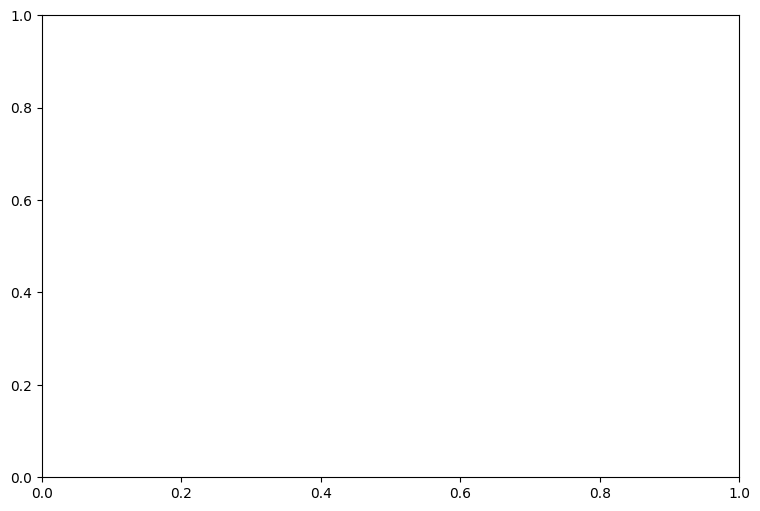

In [20]:
plt.figure(figsize=(9,6))
for group_name in mean_accuracies.keys():
    color = colors.get(group_name, "black")

    plt.plot(relative_time_axis, mean_accuracies[group_name], label=group_name, color=color, linewidth=2.5)
    plt.fill_between(relative_time_axis, lower_bounds[group_name], upper_bounds[group_name], color=color, alpha=0.2)

plt.xlabel('Time from change onset (ms)')
plt.ylabel('decoding accuracy')
plt.title('lick decoding')